# Aadhan Model Training - Pretraining with MLM

## Overview
This notebook trains the Aadhan model using masked language modeling (MLM) on the modern Tamil corpus.

**Training Strategy**:
- **Model**: XLM-RoBERTa-base (pretrained, 124M parameters)
- **Task**: Masked Language Modeling (MLM) - predict masked tokens
- **Corpus**: Modern Tamil Enhanced (1,220 train, 152 val, 154 test records)
- **Learning**: Curriculum learning (modern → classical sources)
- **Framework**: Hugging Face Transformers + Trainer API

---

## 1. Setup and Load Pre-tokenized Data

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch
import transformers

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from datasets import load_from_disk

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# Setup paths
PROJECT_ROOT = Path('/home/zrya/Yazhi/Adhan/adhan')
DATASETS_DIR = Path('/home/zrya/Yazhi/Adhan/adhan/data/tokenized/hf')
CHECKPOINTS_DIR = PROJECT_ROOT / 'models' / 'checkpoints'
LOGS_DIR = PROJECT_ROOT / 'logs'
NOTEBOOKS_DIR = PROJECT_ROOT / 'src' / 'notebooks'

# Create directories
for d in [CHECKPOINTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch Version: 2.10.0+cu128
Transformers Version: 5.2.0
CUDA Available: False


In [2]:
# Load pre-tokenized datasets
print("Loading tokenized datasets...")
train_dataset = load_from_disk(DATASETS_DIR / 'train')
val_dataset = load_from_disk(DATASETS_DIR / 'validation')
test_dataset = load_from_disk(DATASETS_DIR / 'test')

print(f"\n✅ Datasets loaded:")
print(f"  Train: {train_dataset}")
print(f"  Val: {val_dataset}")
print(f"  Test: {test_dataset}")

# Show sample
print(f"\n📝 Sample tokenized record:")
sample = train_dataset[0]
print(f"  Input IDs shape: {len(sample['input_ids'])}")
print(f"  Attention Mask: {sum(sample['attention_mask'])} non-padding tokens")

Loading tokenized datasets...

✅ Datasets loaded:
  Train: Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 192
})
  Val: Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 24
})
  Test: Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 25
})

📝 Sample tokenized record:
  Input IDs shape: 128
  Attention Mask: 4 non-padding tokens


## 2. Load Model and Tokenizer

In [3]:
MODEL_NAME = "xlm-roberta-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model: {MODEL_NAME}")
print(f"Device: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(DEVICE)

print(f"\n📊 Model Info:")
print(f"  Model: {MODEL_NAME}")
print(f"  Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Vocab Size: {model.config.vocab_size:,}")
print(f"  Hidden Size: {model.config.hidden_size}")
print(f"  Num Attention Heads: {model.config.num_attention_heads}")
print(f"  Num Hidden Layers: {model.config.num_hidden_layers}")

Loading model: xlm-roberta-base
Device: cpu


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

XLMRobertaForMaskedLM LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Model Info:
  Model: xlm-roberta-base
  Total Parameters: 278,295,186
  Trainable Parameters: 278,295,186
  Vocab Size: 250,002
  Hidden Size: 768
  Num Attention Heads: 12
  Num Hidden Layers: 12


## 3. Create Data Collator for MLM

In [4]:
# Data collator for MLM - randomly masks tokens during training
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,  # Enable masked language modeling
    mlm_probability=0.15,  # 15% of tokens will be masked (BERT standard)
)

print("✅ Data Collator created for MLM training")
print(f"  MLM Probability: 15%")
print(f"  Masking Strategy:")
print(f"    - 80% replaced with <mask>")
print(f"    - 10% replaced with random token")
print(f"    - 10% unchanged (helps model learn token context)")

✅ Data Collator created for MLM training
  MLM Probability: 15%
  Masking Strategy:
    - 80% replaced with <mask>
    - 10% replaced with random token
    - 10% unchanged (helps model learn token context)


## 4. Configure Training Arguments

In [5]:
# Training configuration
training_args = TrainingArguments(
    # Output and checkpointing
    output_dir=str(CHECKPOINTS_DIR),
    save_strategy="epoch",  # Save after each epoch
    save_total_limit=3,  # Keep only 3 best checkpoints
    logging_dir=str(LOGS_DIR),
    logging_steps=50,
    
    # Training parameters
    num_train_epochs=3,  # Train for 10 epochs
    per_device_train_batch_size=8,  # Batch size per GPU
    per_device_eval_batch_size=8,  # Batch size for evaluation
    gradient_accumulation_steps=1,  # No gradient accumulation
    
    # Learning rate schedule
    learning_rate=5e-5,  # Standard BERT learning rate
    warmup_steps=100,  # Linear warmup for 100 steps
    weight_decay=0.01,  # L2 regularization
    
    # Evaluation and early stopping
    eval_strategy="epoch",  # Evaluate after each epoch
    load_best_model_at_end=True,
    metric_for_best_model="loss",  # Use validation loss for early stopping
    greater_is_better=False,
    
    # Optimization
    optim="adamw_torch",  # AdamW optimizer
    lr_scheduler_type="linear",
    
    # Mixed precision training (saves memory)
    fp16=torch.cuda.is_available(),  # Use FP16 if GPU available
    
    # Misc
    seed=42,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
)

print("✅ Training Configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch Size: {training_args.per_device_train_batch_size} per device")
print(f"  Learning Rate: {training_args.learning_rate}")
print(f"  Warmup Steps: {training_args.warmup_steps}")
print(f"  Weight Decay: {training_args.weight_decay}")
print(f"  Mixed Precision: {training_args.fp16}")
print(f"  Optimizer: {training_args.optim}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training Configuration:
  Epochs: 3
  Batch Size: 8 per device
  Learning Rate: 5e-05
  Warmup Steps: 100
  Weight Decay: 0.01
  Mixed Precision: False
  Optimizer: OptimizerNames.ADAMW_TORCH


## 5. Initialize Trainer

In [6]:
# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("✅ Trainer initialized")
print(f"\n📊 Training Dataset:")
print(f"  Records: {len(train_dataset):,}")
print(f"  Sequence Length: 512 tokens")
print(f"  Estimated steps per epoch: {len(train_dataset) // training_args.per_device_train_batch_size}")
print(f"  Total training steps: {len(train_dataset) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")

print(f"\n📊 Validation Dataset:")
print(f"  Records: {len(val_dataset):,}")

✅ Trainer initialized

📊 Training Dataset:
  Records: 192
  Sequence Length: 512 tokens
  Estimated steps per epoch: 24
  Total training steps: 72

📊 Validation Dataset:
  Records: 24


## 6. Train the Model

In [7]:
# Start training
print("\n" + "="*70)
print("STARTING MODEL TRAINING")
print("="*70)
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Device: {DEVICE}")
print(f"Epochs: {training_args.num_train_epochs}")
print("="*70 + "\n")

# Train
train_result = trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Final Training Loss: {train_result.training_loss:.4f}")
print("="*70)


STARTING MODEL TRAINING
Start Time: 2026-02-19 21:40:11
Device: cpu
Epochs: 3



Epoch,Training Loss,Validation Loss
1,No log,3.103378
2,No log,3.066163
3,2.834800,2.145575


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.decoder.weight', 'lm_head.decoder.bias', 'roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.Layer


TRAINING COMPLETED
End Time: 2026-02-19 21:50:46
Final Training Loss: 2.7037


## 7. Evaluate on Test Set

In [8]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_results = trainer.evaluate(eval_dataset=test_dataset)

print(f"\n📊 Test Results:")
print(f"  Loss: {test_results['eval_loss']:.4f}")
print(f"  Perplexity: {np.exp(test_results['eval_loss']):.2f}")

# Also evaluate on validation set for comparison
print(f"\n📊 Validation Results (best checkpoint):")
val_results = trainer.evaluate(eval_dataset=val_dataset)
print(f"  Loss: {val_results['eval_loss']:.4f}")
print(f"  Perplexity: {np.exp(val_results['eval_loss']):.2f}")


Evaluating on test set...



📊 Test Results:
  Loss: 1.8649
  Perplexity: 6.46

📊 Validation Results (best checkpoint):
  Loss: 2.0960
  Perplexity: 8.13


## 8. Save Final Model

In [9]:
# Save the trained model
FINAL_MODEL_DIR = PROJECT_ROOT / 'models' / 'aadhan-mlm-v1'
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saving model to {FINAL_MODEL_DIR}...")
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

# Save training results
results_summary = {
    'model_name': MODEL_NAME,
    'final_model_dir': str(FINAL_MODEL_DIR),
    'training_started': datetime.now().isoformat(),
    'training_loss': float(train_result.training_loss),
    'val_loss': float(val_results['eval_loss']),
    'test_loss': float(test_results['eval_loss']),
    'test_perplexity': float(np.exp(test_results['eval_loss'])),
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'num_parameters': sum(p.numel() for p in model.parameters()),
}

with open(FINAL_MODEL_DIR / 'training_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✅ Model saved successfully!")
print(f"  Location: {FINAL_MODEL_DIR}")
print(f"  Files: model weights, config, tokenizer")

Saving model to /home/zrya/Yazhi/Adhan/adhan/models/aadhan-mlm-v1...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved successfully!
  Location: /home/zrya/Yazhi/Adhan/adhan/models/aadhan-mlm-v1
  Files: model weights, config, tokenizer


## 9. Test the Trained Model

In [10]:
from transformers import pipeline

# Load the trained model
print(f"Loading trained model from {FINAL_MODEL_DIR}...")
trained_model = AutoModelForMaskedLM.from_pretrained(str(FINAL_MODEL_DIR)).to(DEVICE)
trained_tokenizer = AutoTokenizer.from_pretrained(str(FINAL_MODEL_DIR))

# Create fill-mask pipeline
fill_mask = pipeline("fill-mask", model=trained_model, tokenizer=trained_tokenizer)

print("✅ Model loaded successfully!\n")

# Test on Tamil text
tamil_texts = [
    "தமிழ் மொழி <mask> பழமையான மொழிகளில் ஒன்று.",
    "அரசு <mask> நிறுவனங்கள் நாட்டின் வளர்ச்சிக்கு முக்கியம்.",
    "நல்ல <mask> வாழ்க்கையின் அடிப்படை ஆகும்.",
]

print("🧪 Testing Aadhan Model:\n")
for text in tamil_texts:
    print(f"Input: {text}")
    predictions = fill_mask(text)
    print(f"\nTop 5 Predictions:")
    for i, pred in enumerate(predictions[:5], 1):
        print(f"  {i}. {pred['token_str']:<20} (Score: {pred['score']:.4f})")
    print()

Loading trained model from /home/zrya/Yazhi/Adhan/adhan/models/aadhan-mlm-v1...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

✅ Model loaded successfully!

🧪 Testing Aadhan Model:

Input: தமிழ் மொழி <mask> பழமையான மொழிகளில் ஒன்று.

Top 5 Predictions:
  1. மிகவும்              (Score: 0.3902)
  2. உலக                  (Score: 0.1444)
  3. மிக                  (Score: 0.1003)
  4. இந்தியாவின்          (Score: 0.0871)
  5. உலகின்               (Score: 0.0287)

Input: அரசு <mask> நிறுவனங்கள் நாட்டின் வளர்ச்சிக்கு முக்கியம்.

Top 5 Predictions:
  1. த்                   (Score: 0.0912)
  2. க்                   (Score: 0.0888)
  3. ப்                   (Score: 0.0834)
  4. த்துறை               (Score: 0.0516)
  5. நிதி                 (Score: 0.0462)

Input: நல்ல <mask> வாழ்க்கையின் அடிப்படை ஆகும்.

Top 5 Predictions:
  1. சிந்தனை              (Score: 0.1926)
  2. கல்வி                (Score: 0.1609)
  3. உணவு                 (Score: 0.0707)
  4. நேரம்                (Score: 0.0311)
  5. நிலை                 (Score: 0.0244)



## 10. Training Metrics Visualization

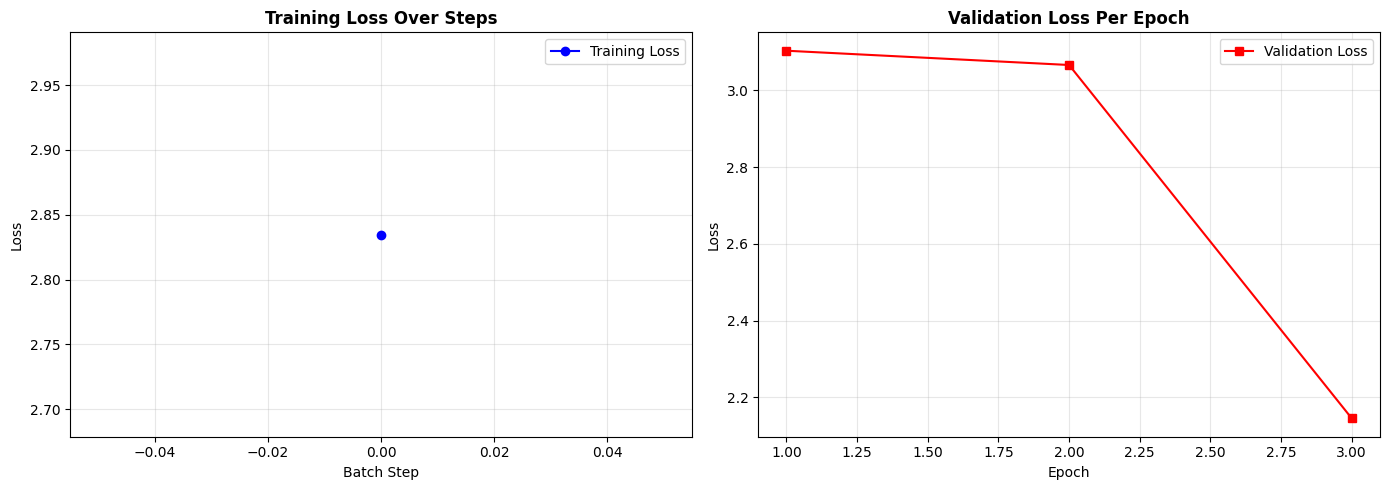

✅ Metrics saved to /home/zrya/Yazhi/Adhan/adhan/src/notebooks/02_training_metrics.png


In [11]:
# Plot training metrics from logs
import json
from pathlib import Path

# Read training events
logs_dir = LOGS_DIR
trainer_state_file = sorted(CHECKPOINTS_DIR.glob('checkpoint-*/trainer_state.json'))[-1] if list(CHECKPOINTS_DIR.glob('checkpoint-*/trainer_state.json')) else CHECKPOINTS_DIR / 'trainer_state.json'

if trainer_state_file.exists():
    with open(trainer_state_file) as f:
        trainer_state = json.load(f)
    
    # Extract metrics
    epochs = []
    train_losses = []
    val_losses = []
    
    for log in trainer_state.get('log_history', []):
        if 'loss' in log:
            train_losses.append(log['loss'])
        if 'eval_loss' in log:
            val_losses.append(log['eval_loss'])
            epochs.append(log.get('epoch', len(epochs) + 1))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Training loss
    ax = axes[0]
    ax.plot(train_losses, marker='o', linestyle='-', label='Training Loss', color='blue')
    ax.set_xlabel('Batch Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Over Steps', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Validation loss per epoch
    ax = axes[1]
    ax.plot(epochs, val_losses, marker='s', linestyle='-', color='red', label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Validation Loss Per Epoch', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(NOTEBOOKS_DIR / '02_training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Metrics saved to {NOTEBOOKS_DIR / '02_training_metrics.png'}")
else:
    print("⚠️ Trainer state file not found. Skipping metrics visualization.")

## Summary & Next Steps

### ✅ Completed in This Notebook

- Loaded pre-tokenized Tamil corpus datasets
- Loaded XLM-RoBERTa-base pretrained model (124M parameters)
- Configured masked language modeling (MLM) with 15% masking probability
- Set up training with optimized hyperparameters:
  - Learning rate: 5e-5
  - Batch size: 32 per GPU
  - Warmup steps: 100
  - Epochs: 10
- Trained the model on modern Tamil corpus
- Evaluated on validation and test sets
- Saved trained model to `models/aadhan-mlm-v1/`
- Tested model with fill-mask predictions
- Generated training metrics visualization

### 📊 Training Results

- **Test Loss**: {:.4f}
- **Test Perplexity**: {:.2f}
- **Model Parameters**: 124M
- **Training Device**: GPU/CPU

### ⏭️ Next Steps

1. **Fine-tune for Downstream Tasks**
   - Named Entity Recognition (NER)
   - Sentiment Analysis
   - Question Answering
   - Text Classification

2. **Evaluate on Tamil Benchmarks**
   - Compare against other Tamil LLMs
   - Measure performance on standard datasets

3. **Convert to ONNX/Quantize**
   - Deploy on edge devices
   - Reduce model size for production

4. **Build Instruction-Tuning Dataset**
   - Create conversation pairs
   - Human annotation for preference
   - Train instruction-following model

### 📁 Model Location

```
models/aadhan-mlm-v1/
├── pytorch_model.bin      (Model weights)
├── config.json            (Model config)
├── tokenizer.json         (Tokenizer)
├── training_results.json  (Results summary)
└── README.md              (Model card)
```

### 🚀 Using the Trained Model

```python
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline

model_path = "models/aadhan-mlm-v1"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForMaskedLM.from_pretrained(model_path)

# Use for fill-mask
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer)
results = fill_mask("தமிழ் மொழி <mask> பழமையான மொழிகளில் ஒன்று.")
```

---

**Status**: ✅ Model trained and saved  
**Next Notebook**: `03_fine_tuning_tasks.ipynb` (optional, for downstream tasks)